### Cluster 3 (3 companies, 3 bankrupt - 100% rate)
### Strategy: Data Augmentation + Stacking (Compliance Model)

In [16]:
import pandas as pd
import numpy as np
import joblib
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [17]:
# Configuration
CLUSTER_ID = 3
INPUT_FILE = f"cluster_{CLUSTER_ID}.csv"
FEATURE_FILE = "top_features_for_clustering.joblib"
OUTPUT_MODEL = f"cluster{CLUSTER_ID}_stacking.joblib"
RANDOM_STATE = 0

# Data Loading
print(f"Loading data for Cluster {CLUSTER_ID}...")
df = pd.read_csv(INPUT_FILE)
print(f"Shape: {df.shape}")
print(f"Class Distribution:\n{df['Bankrupt?'].value_counts()}")

Loading data for Cluster 3...
Shape: (3, 98)
Class Distribution:
Bankrupt?
1    3
Name: count, dtype: int64


In [18]:
features_to_use = joblib.load(FEATURE_FILE)
print(f"Loaded {len(features_to_use)} features.")

X = df[features_to_use]
y = df["Bankrupt?"]

Loaded 40 features.


In [19]:
print("\nInjecting synthetic negative samples for stability...")

# Duplicate the Real Positives
X_real_aug = pd.concat([X] * 5, ignore_index=True)
y_real_aug = pd.concat([y] * 5, ignore_index=True)

# Create Synthetic Negatives (5 rows of random noise)
np.random.seed(RANDOM_STATE)
X_noise = pd.DataFrame(
    np.random.normal(loc=0, scale=2, size=(5, X.shape[1])), 
    columns=X.columns
)
y_noise = pd.Series([0] * 5) 

# Combine Real Positives and Synthetic Negatives
X_train = pd.concat([X_real_aug, X_noise], ignore_index=True)
y_train = pd.concat([y_real_aug, y_noise], ignore_index=True)

print(f"Training Set Shape: {X_train.shape}")
print(f"Training Class Dist:\n{y_train.value_counts()}")


Injecting synthetic negative samples for stability...
Training Set Shape: (20, 40)
Training Class Dist:
1    15
0     5
Name: count, dtype: int64


In [20]:
# Define Base & Stacking Model
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,
    random_state=RANDOM_STATE,
)

knn = KNeighborsClassifier(
    n_neighbors=3
)

dt = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)

estimators = [
    ('rf', rf),
    ('knn', knn),
    ('dt', dt)
]

stacking_layer = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=2,
    n_jobs=-1
)

clf_stack = make_pipeline(
    StandardScaler(),
    PCA(n_components=3, random_state=RANDOM_STATE),
    stacking_layer
)

clf_stack.fit(X_train, y_train)
print("Training Complete.")

Training Complete.


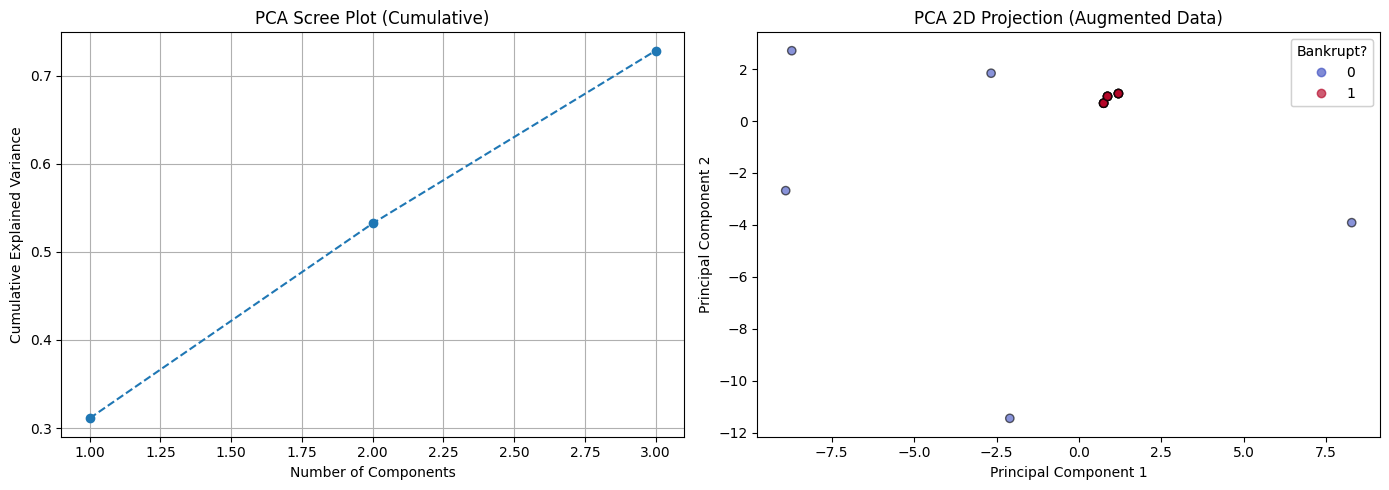

In [21]:
# PCA Analysis 
pca_model = clf_stack.named_steps['pca']
explained_variance = np.cumsum(pca_model.explained_variance_ratio_)
X_train_pca = clf_stack[:-1].transform(X_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree Plot
axes[0].plot(range(1, 4), explained_variance, marker='o', linestyle='--')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA Scree Plot (Cumulative)')
axes[0].grid(True)

# 2D Scatter Projection (PC1 vs PC2)
scatter = axes[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.6, edgecolors='k')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].set_title('PCA 2D Projection (Augmented Data)')
legend1 = axes[1].legend(*scatter.legend_elements(), title="Bankrupt?")
axes[1].add_artist(legend1)

plt.tight_layout()
plt.show()

RESULTS FOR TABLE 3 (Cluster 3)

Base Model Performance (on Original Data after transform):
Base: rf
Confusion Matrix: [[0, 0], [0, 3]]
Eq(1) Accuracy: 1.0000
Base: knn
Confusion Matrix: [[0, 0], [0, 3]]
Eq(1) Accuracy: 1.0000
Base: dt
Confusion Matrix: [[0, 0], [0, 3]]
Eq(1) Accuracy: 1.0000

Stacking Model Performance (Final on Original Data):
STACKING MODEL
Confusion Matrix: [[0, 0], [0, 3]]
Eq(1) Accuracy: 1.0000


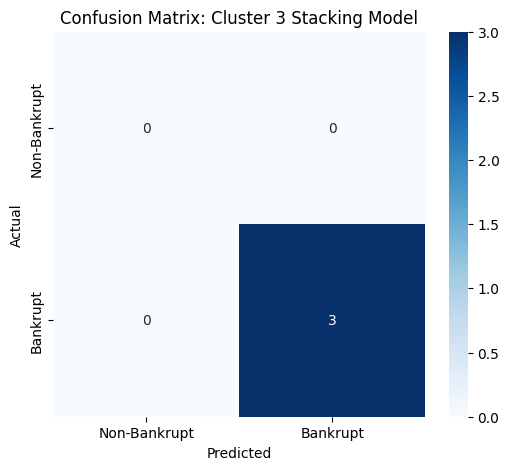


Model saved to cluster3_stacking.joblib
Stats for Table 3 -> TT: 3, TF: 0, N_features: 3


In [22]:
# Evaluation
print(f"RESULTS FOR TABLE 3 (Cluster {CLUSTER_ID})")

def get_metrics(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    FF, FT, TF, TT = cm.ravel()
    acc_eq1 = TT / (TF + TT) if (TF + TT) > 0 else 0
    print(f"{name}")
    print(f"Confusion Matrix: [[{FF}, {FT}], [{TF}, {TT}]]")
    print(f"Eq(1) Accuracy: {acc_eq1:.4f}")
    return FF, FT, TF, TT, acc_eq1

X_transformed = clf_stack[:-1].transform(X) 

# Base Models
print("\nBase Model Performance (on Original Data after transform):")
stacking_estimator = clf_stack[-1]

for name, est in stacking_estimator.named_estimators_.items():
    y_pred_base = est.predict(X_transformed)
    get_metrics(y, y_pred_base, f"Base: {name}")

# Stacking Model
print("\nStacking Model Performance (Final on Original Data):")
y_pred_stack = clf_stack.predict(X)
FF, FT, TF, TT, acc_eq1 = get_metrics(y, y_pred_stack, "STACKING MODEL")

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y, y_pred_stack, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Bankrupt', 'Bankrupt'],
            yticklabels=['Non-Bankrupt', 'Bankrupt'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix: Cluster {CLUSTER_ID} Stacking Model')
plt.show()

model_package = {
    "cluster_id": CLUSTER_ID,
    "features": features_to_use,
    "model": clf_stack, 
    "stats": {"TT": TT, "TF": TF, "N_features": 3}
}

joblib.dump(model_package, OUTPUT_MODEL)
print(f"\nModel saved to {OUTPUT_MODEL}")
print(f"Stats for Table 3 -> TT: {TT}, TF: {TF}, N_features: 3")

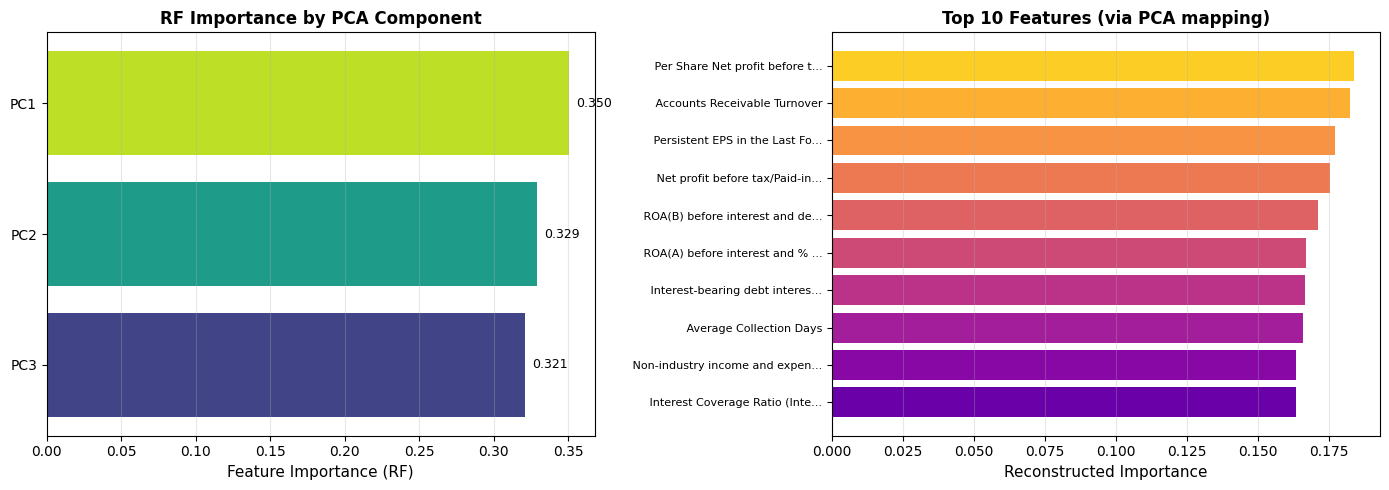


Top 10 Most Important Features:
   1.  Per Share Net profit before tax (Yuan ¥)          : 0.1837
   2.  Accounts Receivable Turnover                      : 0.1822
   3.  Persistent EPS in the Last Four Seasons           : 0.1771
   4.  Net profit before tax/Paid-in capital             : 0.1754
   5.  ROA(B) before interest and depreciation after tax : 0.1711
   6.  ROA(A) before interest and % after tax            : 0.1670
   7.  Interest-bearing debt interest rate               : 0.1666
   8.  Average Collection Days                           : 0.1656
   9.  Non-industry income and expenditure/revenue       : 0.1634
  10.  Interest Coverage Ratio (Interest expense to EBIT : 0.1632

Feature importance plot saved to cluster3_feature_importance.png


In [23]:
# Feature Importance Analysis from Random Forest Base Model
stacking_estimator = clf_stack.named_steps['stackingclassifier']

# Get the RF model
rf_model = stacking_estimator.named_estimators_['rf']

pca_importances = rf_model.feature_importances_
pca_model = clf_stack.named_steps['pca']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
pca_comp_names = [f'PC{i+1}' for i in range(len(pca_importances))]
bars1 = ax1.barh(pca_comp_names[::-1], pca_importances[::-1], 
                  color=plt.cm.viridis(np.linspace(0.2, 0.9, len(pca_importances))))
ax1.set_xlabel('Feature Importance (RF)', fontsize=11)
ax1.set_title('RF Importance by PCA Component', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

for bar, val in zip(bars1, pca_importances[::-1]):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center', fontsize=9)

original_feature_importance = np.abs(pca_model.components_.T) @ pca_importances
feature_importance_df = pd.Series(original_feature_importance, 
                                   index=features_to_use).sort_values(ascending=False)

top_features = feature_importance_df.head(10)

ax2 = axes[1]
short_names = [name[:30] + '...' if len(name) > 30 else name 
               for name in top_features.index[::-1]]
bars2 = ax2.barh(range(len(top_features)), top_features.values[::-1], 
                  color=plt.cm.plasma(np.linspace(0.2, 0.9, len(top_features))))
ax2.set_yticks(range(len(top_features)))
ax2.set_yticklabels(short_names, fontsize=8)
ax2.set_xlabel('Reconstructed Importance', fontsize=11)
ax2.set_title('Top 10 Features (via PCA mapping)', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f"cluster{CLUSTER_ID}_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Most Important Features:")
for i, (feat, imp) in enumerate(feature_importance_df.head(10).items(), 1):
    print(f"  {i:2d}. {feat[:50]:50s} : {imp:.4f}")

print(f"\nFeature importance plot saved to cluster{CLUSTER_ID}_feature_importance.png")